# EDA y Baseline Mínimo — News Sentiment Pipeline USD/PEN

Notebook consolidado con parámetros de rango de fechas para ejecutar EDA, baseline, métricas, gráficos, logs y exportación de fechas para contraste con tipo de cambio real USD/PEN.

**Uso:** modifica `START_DATE` y `END_DATE` en la primera celda de código.

## 0. Parámetros de ejecución

- Para analizar desde diciembre 2025: `START_DATE = "2025-12-01"` y `END_DATE = None`.
- Para un rango cerrado: `START_DATE = "2025-12-01"` y `END_DATE = "2026-01-09"`.

In [ ]:
from pathlib import Path
from datetime import datetime
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

# =====================
# PARÁMETROS EDITABLES
# =====================
START_DATE = "2025-12-01"   # fecha inicial
END_DATE = "2026-01-10"             #  fecha final

RANDOM_SEED = 42
TEST_SIZE_RATIO = 0.30

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FIGS_DIR = PROJECT_ROOT / "figs"
LOGS_DIR = PROJECT_ROOT / "logs"
FIGS_DIR.mkdir(exist_ok=True, parents=True)
LOGS_DIR.mkdir(exist_ok=True, parents=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("FIGS_DIR:", FIGS_DIR)
print("LOGS_DIR:", LOGS_DIR)

PROJECT_ROOT: c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline
PROCESSED_DIR: c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\data\processed
FIGS_DIR: c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\figs
LOGS_DIR: c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\logs


## 1. Carga de datos

Se cargan los principales archivos procesados del pipeline:

- `data/processed/news_scores.csv`
- `data/processed/daily_sentiment.csv`
- `data/processed/compare_sentiment_vs_fx.csv`, si existe

In [6]:
def read_csv_if_exists(path: Path):
    if path.exists():
        return pd.read_csv(path)
    print(f"No encontrado: {path}")
    return None

news_scores_path = PROCESSED_DIR / "news_scores.csv"
daily_sentiment_path = PROCESSED_DIR / "daily_sentiment.csv"
compare_fx_path = PROCESSED_DIR / "compare_sentiment_vs_fx.csv"

news_scores = read_csv_if_exists(news_scores_path)
daily_sentiment = read_csv_if_exists(daily_sentiment_path)
compare_fx = read_csv_if_exists(compare_fx_path)

print("news_scores:", None if news_scores is None else news_scores.shape)
print("daily_sentiment:", None if daily_sentiment is None else daily_sentiment.shape)
print("compare_fx:", None if compare_fx is None else compare_fx.shape)

news_scores: (252, 6)
daily_sentiment: (17, 8)
compare_fx: (7, 13)


## 2. Funciones auxiliares

In [7]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df

def find_date_col(df: pd.DataFrame):
    candidates = ["date", "published_at", "datetime", "created_at", "fecha"]
    for c in candidates:
        if c in df.columns:
            return c
    for c in df.columns:
        if "date" in c.lower() or "fecha" in c.lower():
            return c
    return None

def filter_by_date(df: pd.DataFrame, start_date=START_DATE, end_date=END_DATE, date_col=None):
    df = normalize_columns(df)
    if date_col is None:
        date_col = find_date_col(df)
    if date_col is None:
        print("No se encontró columna de fecha. No se aplica filtro temporal.")
        return df, None
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col])
    if start_date is not None:
        df = df[df[date_col] >= pd.to_datetime(start_date)]
    if end_date is not None:
        df = df[df[date_col] <= pd.to_datetime(end_date)]
    df = df.sort_values(date_col).reset_index(drop=True)
    return df, date_col

def detect_daily_sent_col(df: pd.DataFrame):
    candidates = ["sent_index_mean", "sentiment_score", "sent_score", "sent_index", "score", "sentiment", "daily_sentiment"]
    for c in candidates:
        if c in df.columns:
            return c
    for c in df.columns:
        cl = c.lower()
        if ("sent" in cl or "score" in cl) and pd.api.types.is_numeric_dtype(df[c]):
            return c
    return None

def detect_news_volume_col(df: pd.DataFrame):
    candidates = ["n_news_total", "news_count", "n_news", "count", "num_news"]
    for c in candidates:
        if c in df.columns:
            return c
    return None

## 3. EDA de noticias por registro

Se revisan columnas, nulos, duplicados, distribución de modelos y etiquetas de sentimiento.

In [8]:
if news_scores is not None:
    news_scores = normalize_columns(news_scores)
    display(news_scores.head())
    print("Columnas:", news_scores.columns.tolist())
    print("Filas, columnas:", news_scores.shape)
    print("\nNulos por columna:")
    display(news_scores.isnull().sum().sort_values(ascending=False))
    print("Duplicados:", news_scores.duplicated().sum())
else:
    print("No se cargó news_scores.csv")

,news_id,sentiment_model,sentiment_label,p_pos,p_neu,p_neg
0,f189d252-fbab-4511-b40d-aa13a5ced553,ProsusAI/finbert,neu,0.087387,0.884293,0.028320
1,1b608b61-9b10-474a-b406-55e30ef465bd,ProsusAI/finbert,neg,0.186391,0.321443,0.492166
2,a745f9c0-5a1c-4c8d-9019-e2dcf9edaf19,ProsusAI/finbert,neg,0.018685,0.028833,0.952482
3,a08ea519-017a-4139-87d2-1bc0690f56d1,ProsusAI/finbert,neg,0.008754,0.095677,0.895568
4,f3af10ff-790c-49ee-9de2-6b56b95b1e68,pysentimiento/robertuito-sentiment-analysis,neu,0.411082,0.525940,0.062978


Columnas: ['news_id', 'sentiment_model', 'sentiment_label', 'p_pos', 'p_neu', 'p_neg']
Filas, columnas: (252, 6)

Nulos por columna:


news_id            0
sentiment_model    0
sentiment_label    0
p_pos              0
p_neu              0
p_neg              0
dtype: int64

Duplicados: 0


,conteo
sentiment_label,
neu,161
neg,59
pos,32


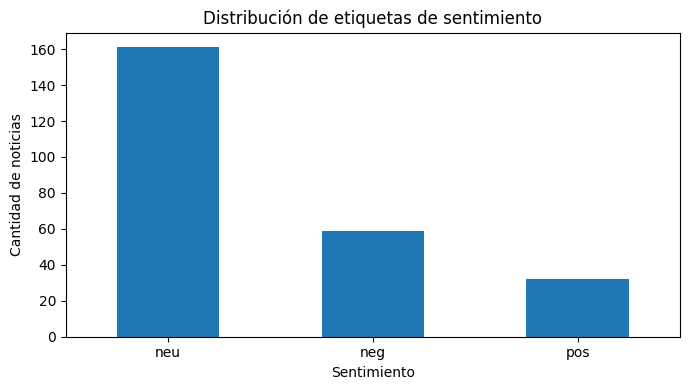

In [9]:
if news_scores is not None and "sentiment_label" in news_scores.columns:
    label_counts = news_scores["sentiment_label"].value_counts(dropna=False)
    display(label_counts.to_frame("conteo"))
    plt.figure(figsize=(7,4))
    label_counts.plot(kind="bar")
    plt.title("Distribución de etiquetas de sentimiento")
    plt.xlabel("Sentimiento")
    plt.ylabel("Cantidad de noticias")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / "eda_sentiment_label_distribution.png", dpi=150)
    plt.show()
else:
    print("No existe columna sentiment_label en news_scores.csv")

,count,mean,std,min,25%,50%,75%,max
p_pos,252.0,0.200684,0.225922,0.003012,0.043654,0.103695,0.266592,0.904940
p_neu,252.0,0.524264,0.226401,0.027673,0.346324,0.566437,0.709083,0.886151
p_neg,252.0,0.275052,0.276274,0.005632,0.055713,0.145511,0.428501,0.969315


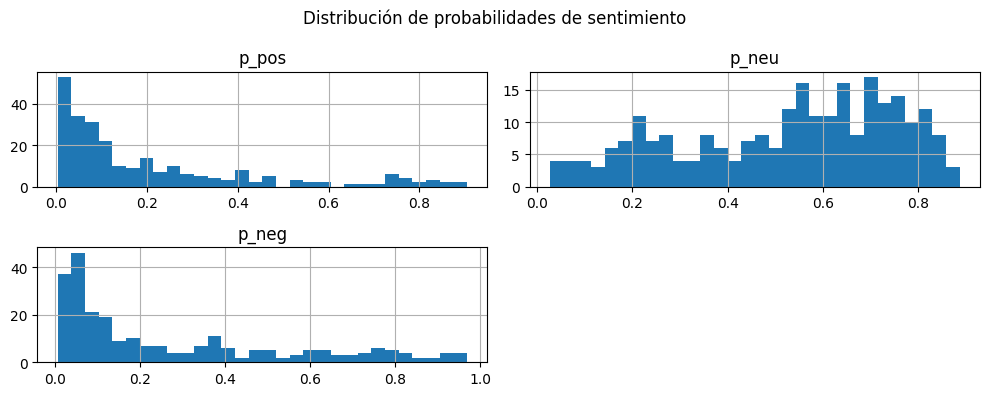

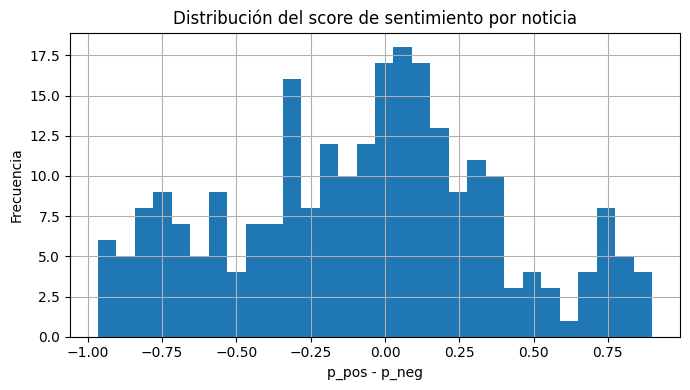

In [10]:
if news_scores is not None:
    prob_cols = [c for c in ["p_pos", "p_neu", "p_neg"] if c in news_scores.columns]
    if prob_cols:
        display(news_scores[prob_cols].describe().T)
        news_scores[prob_cols].hist(bins=30, figsize=(10,4))
        plt.suptitle("Distribución de probabilidades de sentimiento")
        plt.tight_layout()
        plt.savefig(FIGS_DIR / "eda_sentiment_probabilities.png", dpi=150)
        plt.show()
        if "p_pos" in news_scores.columns and "p_neg" in news_scores.columns:
            news_scores["sentiment_score"] = news_scores["p_pos"] - news_scores["p_neg"]
            plt.figure(figsize=(7,4))
            news_scores["sentiment_score"].hist(bins=30)
            plt.title("Distribución del score de sentimiento por noticia")
            plt.xlabel("p_pos - p_neg")
            plt.ylabel("Frecuencia")
            plt.tight_layout()
            plt.savefig(FIGS_DIR / "eda_news_sentiment_score_distribution.png", dpi=150)
            plt.show()
    else:
        print("No se encontraron columnas p_pos/p_neu/p_neg")

### Interpretación — EDA por noticia

- La distribución de etiquetas permite identificar desbalance entre clases.
- Las probabilidades `p_pos`, `p_neu` y `p_neg` permiten construir un score simple: `p_pos - p_neg`.
- Predominio de clases neutrales o scores cercanos a cero puede generar señales agregadas débiles.

## 4. EDA temporal con rango de fechas

Se usa `daily_sentiment.csv` y se aplica el filtro definido por `START_DATE` y `END_DATE`.

In [11]:
if daily_sentiment is None:
    raise FileNotFoundError("No se encontró daily_sentiment.csv. Ejecuta primero el pipeline o verifica la ruta.")

daily_sentiment = normalize_columns(daily_sentiment)
daily, date_col = filter_by_date(daily_sentiment, START_DATE, END_DATE)

print("Columna de fecha:", date_col)
print("Rango configurado:", START_DATE, "a", END_DATE)
print("Rango filtrado:", daily[date_col].min(), "a", daily[date_col].max())
print("Filas luego del filtro:", len(daily))
display(daily.head())
print("Columnas:", daily.columns.tolist())

Columna de fecha: date
Rango configurado: 2025-12-01 a 2026-01-10
Rango filtrado: 2025-12-07 00:00:00 a 2026-01-09 00:00:00
Filas luego del filtro: 12


,date,asset,n_news_total,sent_index_mean,sent_index_strength,share_pos,share_neg,share_neu
0,2025-12-07,USD/PEN,1,-0.933797,-0.889425,0.000000,1.000000,0.00
1,2025-12-12,USD/PEN,1,-0.305775,-0.150492,0.000000,1.000000,0.00
2,2025-12-16,USD/PEN,1,0.059067,0.052233,0.000000,0.000000,1.00
3,2026-01-01,USD/PEN,4,0.162374,0.084535,0.250000,0.000000,0.75
4,2026-01-02,USD/PEN,44,-0.045216,-0.038225,0.204545,0.295455,0.50


Columnas: ['date', 'asset', 'n_news_total', 'sent_index_mean', 'sent_index_strength', 'share_pos', 'share_neg', 'share_neu']


In [12]:
sent_col = detect_daily_sent_col(daily)
volume_col = detect_news_volume_col(daily)
print("Columna de sentimiento diario detectada:", sent_col)
print("Columna de volumen de noticias detectada:", volume_col)
if sent_col is None:
    raise ValueError("No se encontró columna de sentimiento diario. Revisa daily_sentiment.csv")

Columna de sentimiento diario detectada: sent_index_mean
Columna de volumen de noticias detectada: n_news_total


Resumen estadístico del sentimiento diario:


,count,mean,std,min,25%,50%,75%,max
sent_index_mean,12.0,-0.200006,0.339413,-0.933797,-0.314949,-0.070802,-0.008234,0.162374


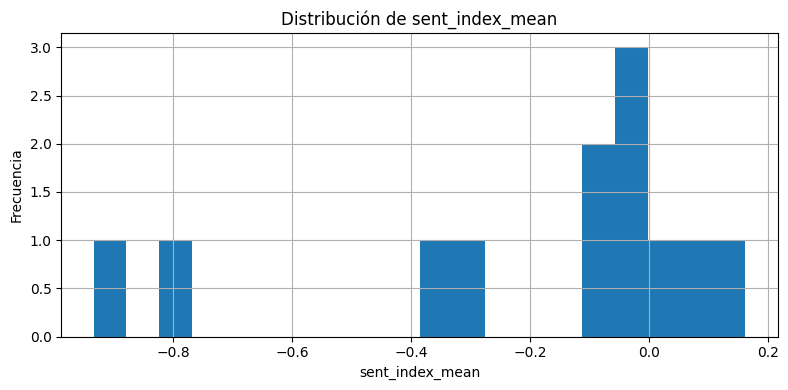

In [13]:
print("Resumen estadístico del sentimiento diario:")
display(daily[[sent_col]].describe().T)

plt.figure(figsize=(8,4))
daily[sent_col].hist(bins=20)
plt.title(f"Distribución de {sent_col}")
plt.xlabel(sent_col)
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(FIGS_DIR / "eda_daily_sentiment_distribution.png", dpi=150)
plt.show()

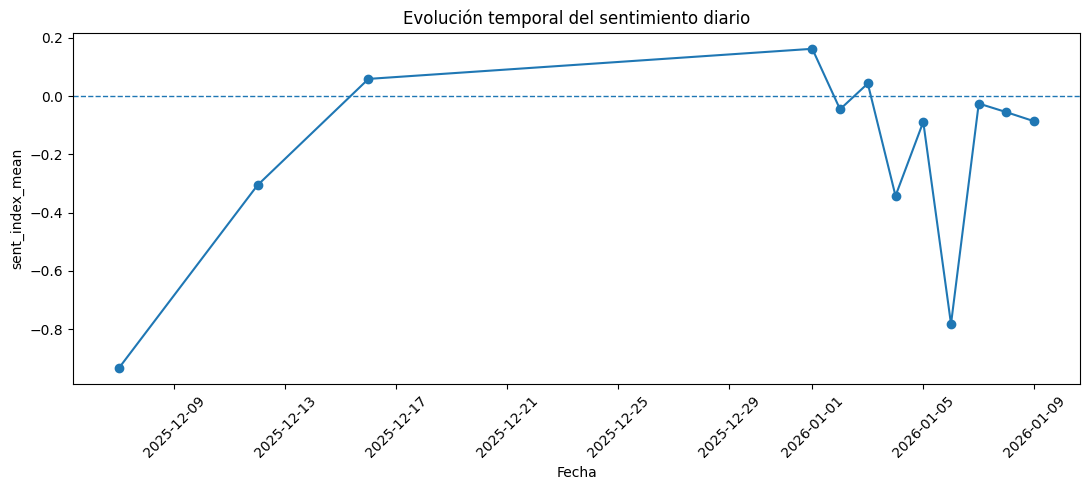

In [14]:
plt.figure(figsize=(11,5))
plt.plot(daily[date_col], daily[sent_col], marker="o")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Evolución temporal del sentimiento diario")
plt.xlabel("Fecha")
plt.ylabel(sent_col)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGS_DIR / "eda_daily_sentiment_timeseries.png", dpi=150)
plt.show()

,count,mean,std,min,25%,50%,75%,max
n_news_total,12.0,20.583333,32.828641,1.0,1.0,3.0,35.75,108.0


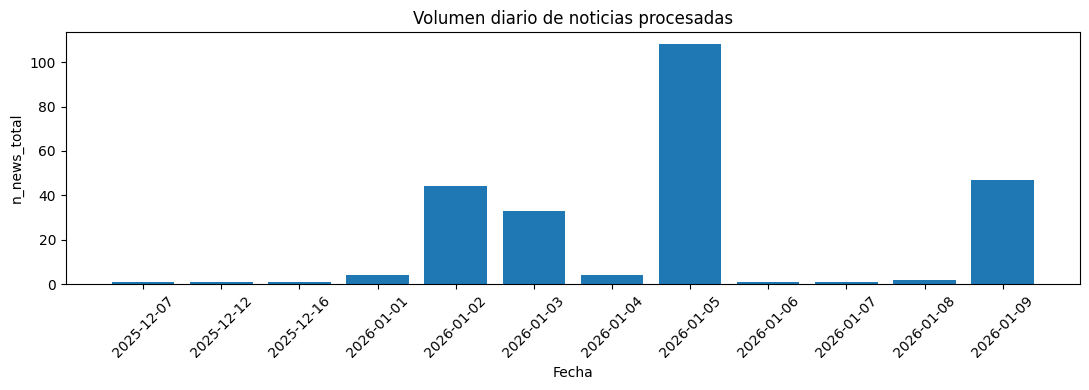

In [15]:
if volume_col is not None:
    display(daily[[volume_col]].describe().T)
    plt.figure(figsize=(11,4))
    plt.bar(daily[date_col].astype(str), daily[volume_col])
    plt.title("Volumen diario de noticias procesadas")
    plt.xlabel("Fecha")
    plt.ylabel(volume_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / "eda_daily_news_volume.png", dpi=150)
    plt.show()
else:
    print("No se detectó columna de volumen diario de noticias.")

### Interpretación — EDA temporal

- El sentimiento diario permite revisar tendencia, concentración por días y variabilidad.
- El volumen diario importa porque días con pocas noticias pueden generar señales menos robustas.
- La comparación con USD/PEN debe hacerse solo en fechas donde existan datos de mercado reales.

## 5. Riesgos identificados

- **Leakage temporal:** se evita usando split temporal en lugar de split aleatorio.
- **Desbalance:** se reporta F1 y matriz de confusión, no solo accuracy.
- **Drift:** el contexto macro cambia, por eso se usa rango de fechas configurable.
- **Bajo número de observaciones:** si el rango elegido tiene pocos días, las métricas pueden ser inestables.

## 6. Preparación del baseline

Se define un target binario según la mediana del sentimiento diario en el rango filtrado:

- `target = 1`: sentimiento diario por encima de la mediana.
- `target = 0`: sentimiento diario menor o igual a la mediana.

Features simples:

- `lag_sent`
- `lag_sent_2`
- `volatility_3`
- `news_volume`

In [16]:
baseline_df = daily[[date_col, sent_col] + ([volume_col] if volume_col is not None else [])].copy()
baseline_df = baseline_df.rename(columns={date_col: "date", sent_col: "sentiment_daily"})
baseline_df["target"] = (baseline_df["sentiment_daily"] > baseline_df["sentiment_daily"].median()).astype(int)
baseline_df["lag_sent"] = baseline_df["sentiment_daily"].shift(1)
baseline_df["lag_sent_2"] = baseline_df["sentiment_daily"].shift(2)
baseline_df["volatility_3"] = baseline_df["sentiment_daily"].rolling(3).std()
if volume_col is not None:
    baseline_df = baseline_df.rename(columns={volume_col: "news_volume"})
else:
    baseline_df["news_volume"] = 1
baseline_df = baseline_df.dropna().reset_index(drop=True)
print("Filas para baseline:", len(baseline_df))
display(baseline_df.head())
print("Balance target:")
display(baseline_df["target"].value_counts().to_frame("conteo"))

Filas para baseline: 10


,date,sentiment_daily,news_volume,target,lag_sent,lag_sent_2,volatility_3
0,2025-12-16,0.059067,1,1,-0.305775,-0.933797,0.502212
1,2026-01-01,0.162374,4,1,0.059067,-0.305775,0.245949
2,2026-01-02,-0.045216,44,1,0.162374,0.059067,0.103795
3,2026-01-03,0.043340,33,1,-0.045216,0.162374,0.104167
4,2026-01-04,-0.342471,4,0,0.043340,-0.045216,0.202094


Balance target:


,conteo
target,
1,6
0,4


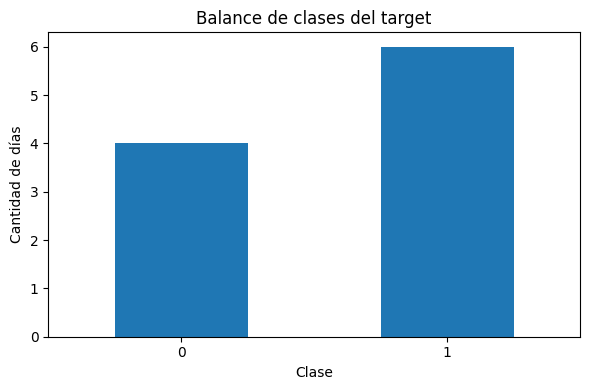

In [17]:
plt.figure(figsize=(6,4))
baseline_df["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Balance de clases del target")
plt.xlabel("Clase")
plt.ylabel("Cantidad de días")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGS_DIR / "baseline_target_balance.png", dpi=150)
plt.show()

## 7. Split temporal

Se usa split temporal para evitar fuga de información.

In [18]:
features = ["lag_sent", "lag_sent_2", "volatility_3", "news_volume"]
X = baseline_df[features]
y = baseline_df["target"]

if len(baseline_df) < 8:
    print("ADVERTENCIA: pocas observaciones. Las métricas pueden ser inestables.")

split_idx = max(1, int(len(baseline_df) * (1 - TEST_SIZE_RATIO)))
if split_idx >= len(baseline_df):
    split_idx = len(baseline_df) - 1

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_train = baseline_df["date"].iloc[:split_idx]
dates_test = baseline_df["date"].iloc[split_idx:]

print("Train:", X_train.shape, dates_train.min(), "a", dates_train.max())
print("Test:", X_test.shape, dates_test.min(), "a", dates_test.max())
print("Balance train:")
display(y_train.value_counts().to_frame("conteo"))
print("Balance test:")
display(y_test.value_counts().to_frame("conteo"))

Train: (7, 4) 2025-12-16 00:00:00 a 2026-01-06 00:00:00
Test: (3, 4) 2026-01-07 00:00:00 a 2026-01-09 00:00:00
Balance train:


,conteo
target,
1,4
0,3


Balance test:


,conteo
target,
1,2
0,1


## 8. Baselines mínimos

Se comparan:

1. `DummyClassifier`: clase más frecuente.
2. `LogisticRegression`: modelo simple con features temporales.

In [19]:
def compute_metrics(y_true, y_pred, model_name):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

models_results = []
predictions = {}

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
models_results.append(compute_metrics(y_test, y_pred_dummy, "Dummy most_frequent"))
predictions["Dummy most_frequent"] = y_pred_dummy

if len(np.unique(y_train)) >= 2:
    logreg = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", random_state=RANDOM_SEED, max_iter=1000))
    ])
    logreg.fit(X_train, y_train)
    y_pred_logreg = logreg.predict(X_test)
    models_results.append(compute_metrics(y_test, y_pred_logreg, "Logistic Regression"))
    predictions["Logistic Regression"] = y_pred_logreg
else:
    print("No se ejecutó LogisticRegression porque y_train contiene una sola clase.")

metrics_df = pd.DataFrame(models_results)
display(metrics_df)

,model,accuracy,f1_weighted,f1_macro
0,Dummy most_frequent,0.666667,0.533333,0.40
1,Logistic Regression,0.333333,0.333333,0.25


In [20]:
best_model_name = metrics_df.sort_values("f1_weighted", ascending=False).iloc[0]["model"]
y_pred_best = predictions[best_model_name]
print("Mejor modelo según F1 weighted:", best_model_name)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best, zero_division=0))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_best, labels=[0,1]))

Mejor modelo según F1 weighted: Dummy most_frequent

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3


Confusion Matrix:

[[0 1]
 [0 2]]


## 9. Resultados y gráfica central

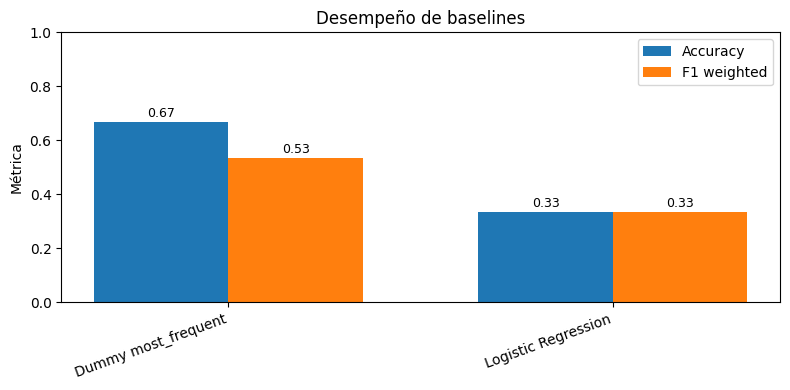

In [21]:
plt.figure(figsize=(8,4))
bar_width = 0.35
x = np.arange(len(metrics_df))
plt.bar(x - bar_width/2, metrics_df["accuracy"], width=bar_width, label="Accuracy")
plt.bar(x + bar_width/2, metrics_df["f1_weighted"], width=bar_width, label="F1 weighted")
plt.xticks(x, metrics_df["model"], rotation=20, ha="right")
plt.ylim(0, 1)
plt.title("Desempeño de baselines")
plt.ylabel("Métrica")
plt.legend()
for i, row in metrics_df.iterrows():
    plt.text(i - bar_width/2, row["accuracy"] + 0.02, f"{row['accuracy']:.2f}", ha="center", fontsize=9)
    plt.text(i + bar_width/2, row["f1_weighted"] + 0.02, f"{row['f1_weighted']:.2f}", ha="center", fontsize=9)
plt.tight_layout()  
plt.savefig(FIGS_DIR / "baseline_metrics_comparison.png", dpi=150)
plt.show()

In [23]:
import pandas as pd

df_daily = pd.read_csv("../data/processed/daily_sentiment.csv")
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily = df_daily.sort_values('date')

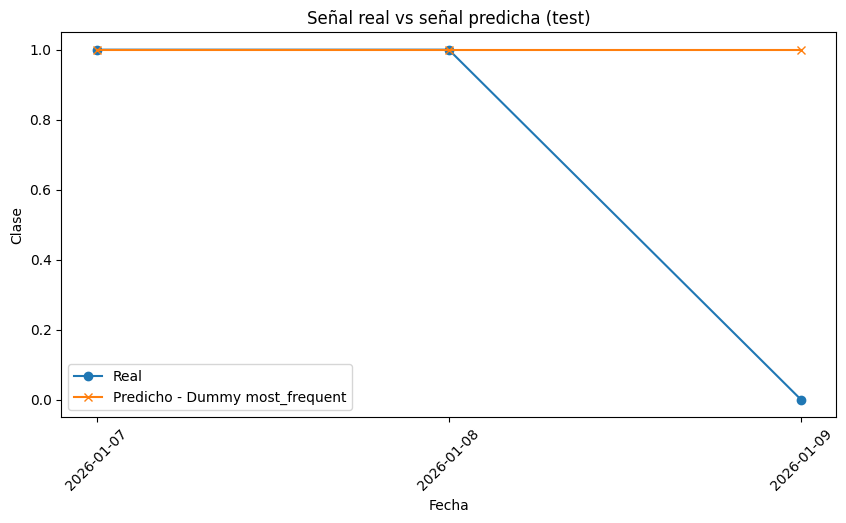

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Usa el dataset correcto
df_plot = df_daily.copy()

# Asegurar fechas
df_plot['date'] = pd.to_datetime(df_plot['date'])
df_plot = df_plot.sort_values('date')

# Fechas del test
dates_test = df_plot['date'].iloc[-len(y_test):]

# Modelo
model_name = "Dummy most_frequent"
y_pred_plot = predictions[model_name]

plt.figure(figsize=(10,5))

plt.plot(dates_test, y_test.values, marker='o', label='Real')
plt.plot(dates_test, y_pred_plot, marker='x', label=f'Predicho - {model_name}')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator())

plt.xticks(rotation=45)
plt.xlabel("Fecha")
plt.ylabel("Clase")
plt.title("Señal real vs señal predicha (test)")
plt.legend()

plt.show()

## 10. Fechas consideradas para buscar tipo de cambio real USD/PEN

Se exporta el rango filtrado y las fechas del test en `logs/dates_for_fx_lookup.json`.

In [25]:
fx_dates = {
    "start_date_configured": START_DATE,
    "end_date_configured": END_DATE,
    "filtered_min_date": str(pd.to_datetime(daily[date_col].min()).date()),
    "filtered_max_date": str(pd.to_datetime(daily[date_col].max()).date()),
    "baseline_min_date": str(pd.to_datetime(baseline_df["date"].min()).date()) if len(baseline_df) else None,
    "baseline_max_date": str(pd.to_datetime(baseline_df["date"].max()).date()) if len(baseline_df) else None,
    "test_dates": [str(pd.to_datetime(d).date()) for d in dates_test],
}
fx_lookup_path = LOGS_DIR / "dates_for_fx_lookup.json"
with open(fx_lookup_path, "w", encoding="utf-8") as f:
    json.dump(fx_dates, f, indent=2, ensure_ascii=False)
print(json.dumps(fx_dates, indent=2, ensure_ascii=False))
print("Archivo guardado en:", fx_lookup_path)

{
  "start_date_configured": "2025-12-01",
  "end_date_configured": "2026-01-10",
  "filtered_min_date": "2025-12-07",
  "filtered_max_date": "2026-01-09",
  "baseline_min_date": "2025-12-16",
  "baseline_max_date": "2026-01-09",
  "test_dates": [
    "2026-01-07",
    "2026-01-08",
    "2026-01-09"
  ]
}
Archivo guardado en: c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\logs\dates_for_fx_lookup.json


In [28]:
import yfinance as yf
import pandas as pd

start = df_plot['date'].min().strftime("%Y-%m-%d")
end = df_plot['date'].max().strftime("%Y-%m-%d")

usdpen = yf.download("PEN=X", start=start, end=end, auto_adjust=False)

# Aplanar columnas si vienen en MultiIndex
if isinstance(usdpen.columns, pd.MultiIndex):
    usdpen.columns = usdpen.columns.get_level_values(0)

# Dejar solo fecha y cierre
usdpen = usdpen.reset_index()
usdpen = usdpen.rename(columns={"Date": "date", "Close": "usdpen_close"})

# Asegurar mismo formato de fecha
usdpen['date'] = pd.to_datetime(usdpen['date']).dt.normalize()
df_plot['date'] = pd.to_datetime(df_plot['date']).dt.normalize()

# Unir datasets
df_fx = df_plot.merge(
    usdpen[['date', 'usdpen_close']],
    on='date',
    how='left'
)

df_fx.head()

[*********************100%***********************]  1 of 1 completed


,date,asset,n_news_total,sent_index_mean,sent_index_strength,share_pos,share_neg,share_neu,usdpen_close
0,2023-11-15,USD/PEN,1,0.076563,0.060824,0.0,0.0,1.0,3.767000
1,2025-06-06,USD/PEN,1,-0.472224,-0.237864,0.0,1.0,0.0,3.626000
2,2025-06-17,USD/PEN,1,-0.037403,-0.030198,0.0,0.0,1.0,3.597500
3,2025-06-18,USD/PEN,1,-0.430519,-0.219767,0.0,0.0,1.0,3.610000
4,2025-11-21,USD/PEN,1,-0.886814,-0.794203,0.0,1.0,0.0,3.310272


In [29]:
df_fx['fx_direction'] = (df_fx['usdpen_close'].diff() > 0).astype(int)
df_fx = df_fx.dropna(subset=['usdpen_close'])

df_fx[['date', 'sent_index_mean', 'usdpen_close', 'fx_direction']].head()

,date,sent_index_mean,usdpen_close,fx_direction
0,2023-11-15,0.076563,3.767000,0
1,2025-06-06,-0.472224,3.626000,0
2,2025-06-17,-0.037403,3.597500,0
3,2025-06-18,-0.430519,3.610000,1
4,2025-11-21,-0.886814,3.310272,0


In [31]:
# Ordenar por fecha
df_fx = df_fx.sort_values("date")

# Variación diaria del USD/PEN
df_fx["fx_change"] = df_fx["usdpen_close"].diff()

# Dirección real:
# 1 = sube USD/PEN
# 0 = baja o no sube USD/PEN
df_fx["fx_direction"] = (df_fx["fx_change"] > 0).astype(int)

# Eliminar primera fila porque no tiene variación previa
df_fx = df_fx.dropna(subset=["fx_change"])

df_fx[["date", "sent_index_mean", "usdpen_close", "fx_change", "fx_direction"]].head()

,date,sent_index_mean,usdpen_close,fx_change,fx_direction
1,2025-06-06,-0.472224,3.626000,-0.141000,0
2,2025-06-17,-0.037403,3.597500,-0.028500,0
3,2025-06-18,-0.430519,3.610000,0.012500,1
4,2025-11-21,-0.886814,3.310272,-0.299728,0
6,2025-12-12,-0.305775,3.368000,0.057728,1


In [34]:
# Tomar solo las últimas fechas equivalentes al conjunto de test
fx_test = df_fx["fx_direction"].iloc[-len(y_test):]
dates_fx_test = df_fx["date"].iloc[-len(y_test):]

# Predicciones de Logistic Regression
y_pred_lr = predictions["Logistic Regression"]

print("Fechas evaluadas:")
print(dates_fx_test)

print("Dirección real USD/PEN:")
print(fx_test.values)

print("Predicción modelo:")
print(y_pred_lr)

Fechas evaluadas:
13   2026-01-06
14   2026-01-07
15   2026-01-08
Name: date, dtype: datetime64[us]
Dirección real USD/PEN:
[1 0 0]
Predicción modelo:
[0 1 1]


In [35]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

acc_fx = accuracy_score(fx_test, y_pred_lr)
f1_fx = f1_score(fx_test, y_pred_lr, zero_division=0)

print("Accuracy vs USD/PEN real:", acc_fx)
print("F1 vs USD/PEN real:", f1_fx)

print("\nClassification Report:\n")
print(classification_report(fx_test, y_pred_lr, zero_division=0))

print("\nConfusion Matrix:\n")
print(confusion_matrix(fx_test, y_pred_lr))

Accuracy vs USD/PEN real: 0.0
F1 vs USD/PEN real: 0.0

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       2.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0


Confusion Matrix:

[[0 2]
 [1 0]]


In [36]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

acc_fx = accuracy_score(fx_test, y_pred_lr)
f1_fx = f1_score(fx_test, y_pred_lr, zero_division=0)

print("Accuracy vs USD/PEN real:", acc_fx)
print("F1 vs USD/PEN real:", f1_fx)

print("\nClassification Report:\n")
print(classification_report(fx_test, y_pred_lr, zero_division=0))

print("\nConfusion Matrix:\n")
print(confusion_matrix(fx_test, y_pred_lr))

Accuracy vs USD/PEN real: 0.0
F1 vs USD/PEN real: 0.0

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       2.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0


Confusion Matrix:

[[0 2]
 [1 0]]


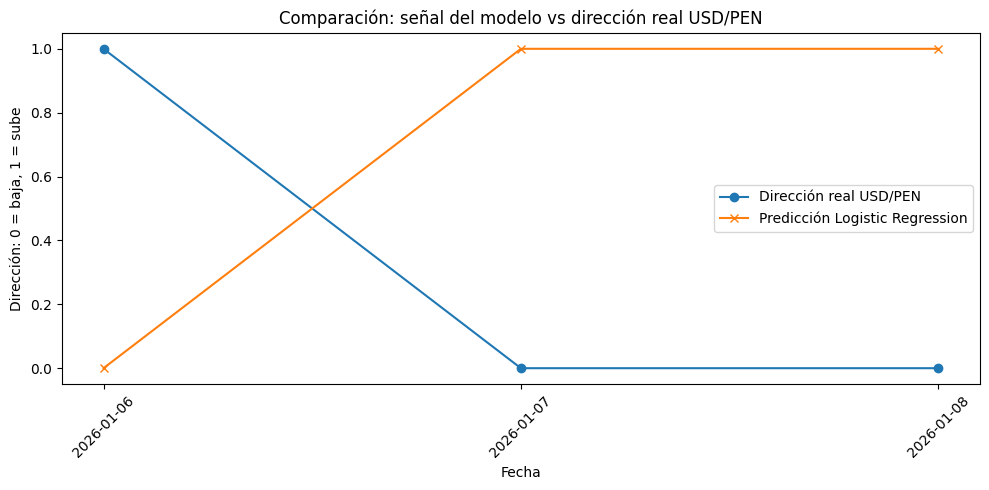

In [37]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(10,5))

plt.plot(dates_fx_test, fx_test.values, marker="o", label="Dirección real USD/PEN")
plt.plot(dates_fx_test, y_pred_lr, marker="x", label="Predicción Logistic Regression")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator())

plt.xticks(rotation=45)
plt.xlabel("Fecha")
plt.ylabel("Dirección: 0 = baja, 1 = sube")
plt.title("Comparación: señal del modelo vs dirección real USD/PEN")
plt.legend()
plt.tight_layout()

plt.savefig(FIGS_DIR / "modelo_vs_usdpen_real.png", dpi=150)
plt.show()

In [39]:
import pandas as pd

# 1. Cargar noticias limpias y scores
df_clean = pd.read_csv("../data/processed/news_clean.csv")
df_scores = pd.read_csv("../data/processed/news_scores.csv")

print("Columnas news_clean:", df_clean.columns.tolist())
print("Columnas news_scores:", df_scores.columns.tolist())

Columnas news_clean: ['news_id', 'source', 'url', 'published_at', 'fetched_at', 'title_raw', 'body_raw', 'content_hash', 'lang_hint', 'reliability_weight']
Columnas news_scores: ['news_id', 'sentiment_model', 'sentiment_label', 'p_pos', 'p_neu', 'p_neg']


In [41]:
print("Columnas df_clean:")
print(df_clean.columns.tolist())

print("\nColumnas df_scores:")
print(df_scores.columns.tolist())

df_news = df_clean.merge(df_scores, on="news_id", how="inner")

print("\nColumnas df_news:")
print(df_news.columns.tolist())

Columnas df_clean:
['news_id', 'source', 'url', 'published_at', 'fetched_at', 'title_raw', 'body_raw', 'content_hash', 'lang_hint', 'reliability_weight']

Columnas df_scores:
['news_id', 'sentiment_model', 'sentiment_label', 'p_pos', 'p_neu', 'p_neg']

Columnas df_news:
['news_id', 'source', 'url', 'published_at', 'fetched_at', 'title_raw', 'body_raw', 'content_hash', 'lang_hint', 'reliability_weight', 'sentiment_model', 'sentiment_label', 'p_pos', 'p_neu', 'p_neg']


In [42]:
# Detectar columna de fecha automáticamente
possible_date_cols = ["date", "published_at", "pub_date", "datetime", "created_at", "fecha"]

date_col = None

for col in possible_date_cols:
    if col in df_news.columns:
        date_col = col
        break

print("Columna de fecha detectada:", date_col)

if date_col is None:
    print("No se encontró columna de fecha. Columnas disponibles:")
    print(df_news.columns.tolist())
else:
    df_news["date"] = pd.to_datetime(df_news[date_col], errors="coerce").dt.normalize()
    df_news = df_news.dropna(subset=["date"])

Columna de fecha detectada: published_at


In [50]:
df_news["sentiment_score"] = df_news["p_pos"] - df_news["p_neg"]

df_news = df_news[
    (df_news["date"] >= pd.to_datetime("2025-12-01")) &
    (df_news["date"] <= pd.to_datetime("2026-01-10"))
]

df_news.head()

,news_id,source,url,published_at,fetched_at,title_raw,body_raw,content_hash,lang_hint,reliability_weight,sentiment_model,sentiment_label,p_pos,p_neu,p_neg,date,sentiment_score


In [44]:
daily_news = (
    df_news
    .groupby("date")
    .agg(
        n_news=("news_id", "count"),
        sentiment_score_mean=("sentiment_score", "mean"),
        sentiment_dominante=("sentiment_label", lambda x: x.value_counts().idxmax()),
        n_positive=("sentiment_label", lambda x: (x == "positive").sum()),
        n_neutral=("sentiment_label", lambda x: (x == "neutral").sum()),
        n_negative=("sentiment_label", lambda x: (x == "negative").sum()),
    )
    .reset_index()
)

daily_news

,date,n_news,sentiment_score_mean,sentiment_dominante,n_positive,n_neutral,n_negative


In [45]:
cols = [
    "date",
    "source",
    "title_raw",
    "sentiment_label",
    "sentiment_score",
    "p_pos",
    "p_neu",
    "p_neg"
]

df_news_detail = df_news[cols].sort_values(
    ["date", "sentiment_score"],
    ascending=[True, False]
)

df_news_detail.head(30)

,date,source,title_raw,sentiment_label,sentiment_score,p_pos,p_neu,p_neg


In [46]:
df_day_fx = daily_news.merge(
    df_fx[["date", "usdpen_close", "fx_change", "fx_direction"]],
    on="date",
    how="left"
)

df_day_fx

,date,n_news,sentiment_score_mean,sentiment_dominante,n_positive,n_neutral,n_negative,usdpen_close,fx_change,fx_direction


In [47]:
df_day_fx_final = df_day_fx[[
    "date",
    "n_news",
    "sentiment_dominante",
    "sentiment_score_mean",
    "n_positive",
    "n_neutral",
    "n_negative",
    "usdpen_close",
    "fx_change",
    "fx_direction"
]]

df_day_fx_final

,date,n_news,sentiment_dominante,sentiment_score_mean,n_positive,n_neutral,n_negative,usdpen_close,fx_change,fx_direction


### Nota para comparación con tipo de cambio real

Para comparar contra USD/PEN real, busca OHLC diario del mismo rango. Puedes usar:

- `open` vs `close` para dirección intradía.
- `close_t` vs `close_t-1` para dirección diaria.

Considera que no todas las fechas con noticias tendrán cotización disponible.

## 11. Logs y reproducibilidad

In [26]:
metrics_log_path = LOGS_DIR / "metrics_baseline.txt"
data_version_path = LOGS_DIR / "data_version.json"
now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
with open(metrics_log_path, "w", encoding="utf-8") as f:
    f.write("EDA + Baseline mínimo - News Sentiment Pipeline USD/PEN\n")
    f.write(f"Fecha de ejecución: {now}\n")
    f.write(f"START_DATE: {START_DATE}\n")
    f.write(f"END_DATE: {END_DATE}\n")
    f.write(f"RANDOM_SEED: {RANDOM_SEED}\n")
    f.write(f"TEST_SIZE_RATIO: {TEST_SIZE_RATIO}\n")
    f.write(f"Filas daily filtrado: {len(daily)}\n")
    f.write(f"Filas baseline: {len(baseline_df)}\n")
    f.write(f"Fecha mínima filtrada: {daily[date_col].min()}\n")
    f.write(f"Fecha máxima filtrada: {daily[date_col].max()}\n")
    f.write("\nMétricas:\n")
    f.write(metrics_df.to_string(index=False))
    f.write("\n\nMejor modelo: " + str(best_model_name))
    f.write("\n\nClassification report:\n")
    f.write(classification_report(y_test, y_pred_best, zero_division=0))
    f.write("\nConfusion matrix:\n")
    f.write(str(confusion_matrix(y_test, y_pred_best, labels=[0,1])))
version_info = {
    "execution_time": now,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "news_scores_exists": news_scores is not None,
    "news_scores_shape": None if news_scores is None else list(news_scores.shape),
    "daily_sentiment_shape_original": list(daily_sentiment.shape),
    "daily_sentiment_shape_filtered": list(daily.shape),
    "baseline_shape": list(baseline_df.shape),
    "sentiment_column_used": sent_col,
    "date_column_used": date_col,
    "volume_column_used": volume_col,
    "features": features,
}
with open(data_version_path, "w", encoding="utf-8") as f:
    json.dump(version_info, f, indent=2, ensure_ascii=False)
print("Log de métricas guardado en:", metrics_log_path)
print("Versión de datos guardada en:", data_version_path)

Log de métricas guardado en: c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\logs\metrics_baseline.txt
Versión de datos guardada en: c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\logs\data_version.json


## 12. Conclusiones accionables

1. **Aumentar cobertura temporal:** ampliar el dataset para reducir inestabilidad.
2. **Integrar USD/PEN real:** unir las fechas exportadas con tipo de cambio real.
3. **Mejorar señal:** incorporar banda neutral.
4. **Agregar features:** fuente, tópico, volumen y fuerza de sentimiento.
5. **Controlar leakage:** mantener split temporal.

## 13. Guion breve para demo interna

1. Mostrar rango de fechas configurable.
2. Explicar EDA por noticia.
3. Explicar EDA temporal.
4. Mostrar riesgos.
5. Ejecutar baseline mínimo y comparar contra dummy.
6. Mostrar gráficos en `figs/` y logs en `logs/`.
7. Cerrar con comparación pendiente contra USD/PEN real y calibración de banda neutral.